## Block encoding circuits for Laplacians with mixed boundary conditions

Here we demonstrate explicit quantum circuits for block encoding Laplacians with mixed boundary conditions in arbitrary dimensions. The boundary conditions can be Dirichlet, von Neumann or Periodic.

In [1]:
import matplotlib.pyplot as plt
import scipy.sparse as sp
import numpy as np

from block_encoding import generate_laplacian_block_encoding
from utils import plot_heatmap, get_circuit_unitary, lap1d_fd, generate_laplacian

### 1D Laplacian


Boundary condition: dirichlet


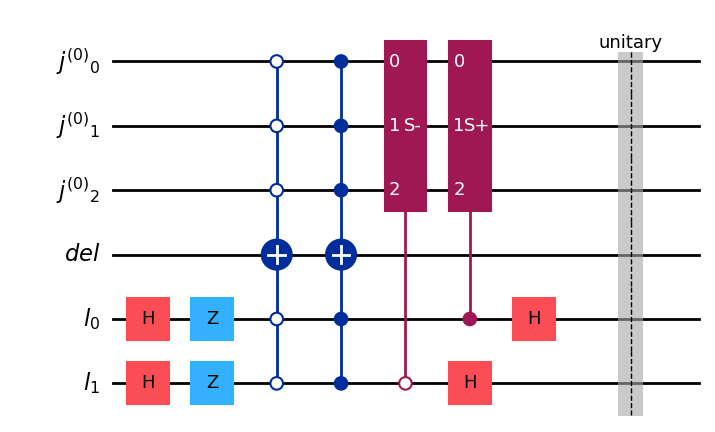

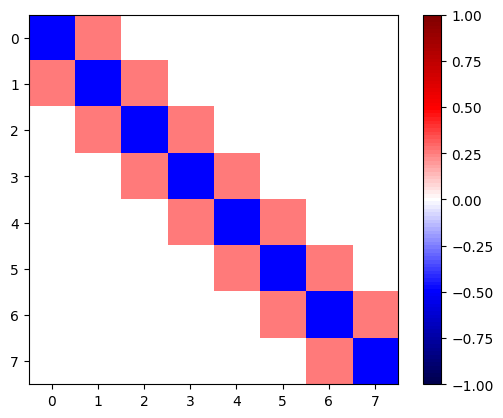

Boundary condition: periodic


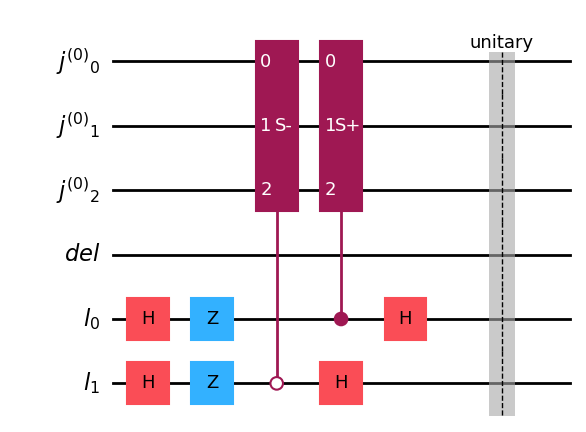

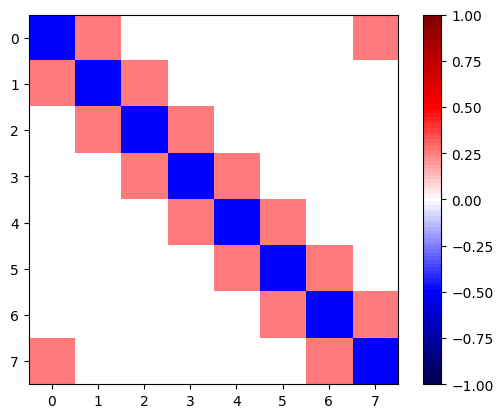

Boundary condition: neumann


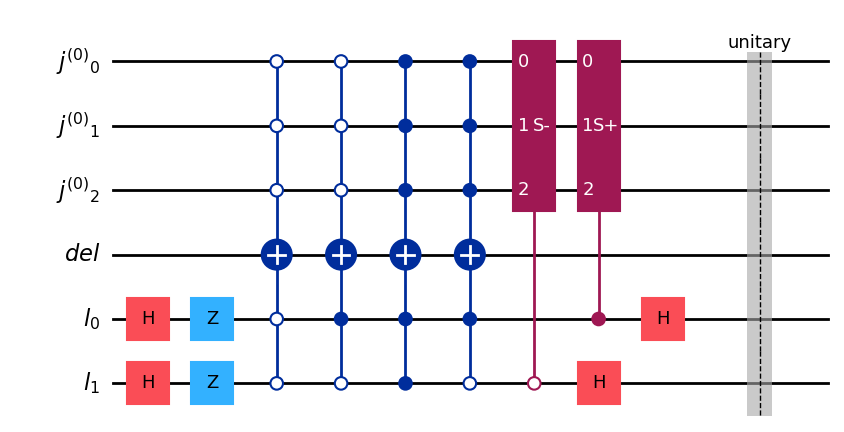

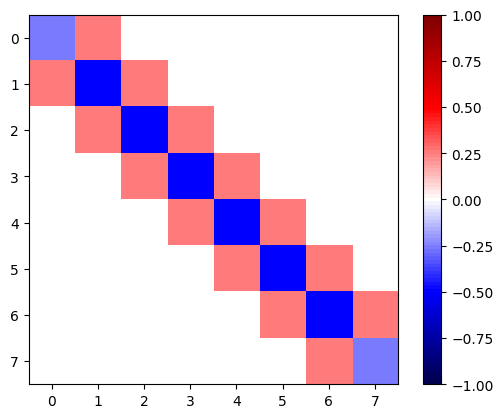

In [2]:
# Heat map and quantum circuit plots of our block encodings of 1D Laplacians
bcs = [("dirichlet",), ("periodic",), ("neumann",)]

for bc in bcs:
    print("Boundary condition:", bc[0])
    nq = 3  # number of qubits, 2^3 = 8 grid points
    qc = generate_laplacian_block_encoding([nq], bcs=bc, save_unitary=True)
    fig = qc.draw(output="mpl")
    display(fig)
    plot_heatmap(qc, [nq], bcs=bc) # matrix obtained after post-processing of the block encoding circuit

### Correctness check for 1D Laplacian

In [3]:
# Checking correctness
test_names = ["1D Dirichlet", "1D Periodic", "1D Neumann"]

for i, bc in enumerate(bcs):
    correct_mat = generate_laplacian((8,), (1,), bc, True).toarray()

    qc = generate_laplacian_block_encoding([3], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, [3])

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

--- PASSED ---	Test 1D Dirichlet
--- PASSED ---	Test 1D Periodic
--- PASSED ---	Test 1D Neumann


## 2D Laplacian 

Boundary condition: dirichlet , periodic


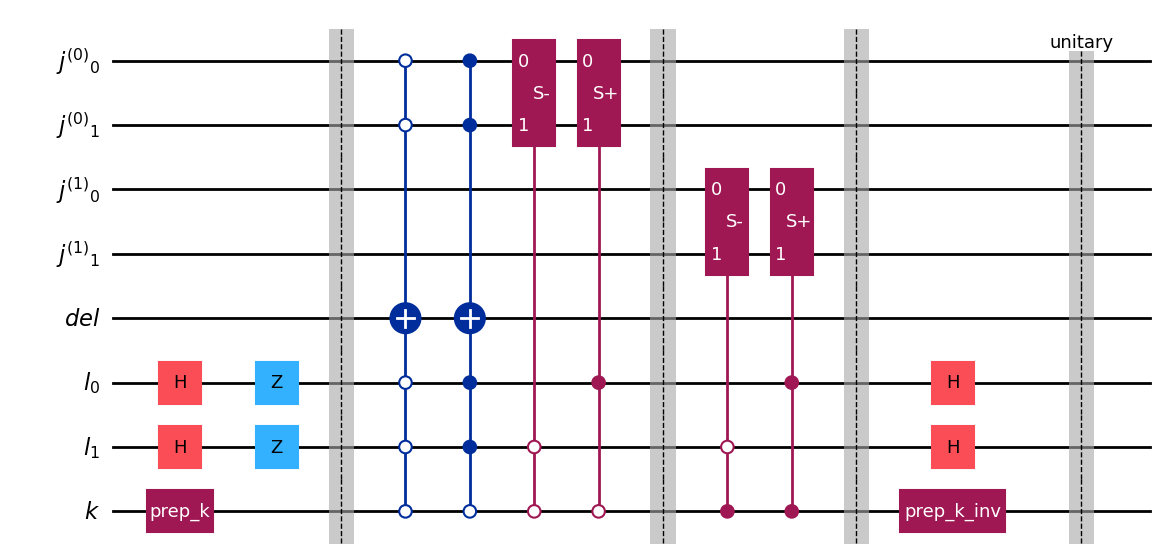

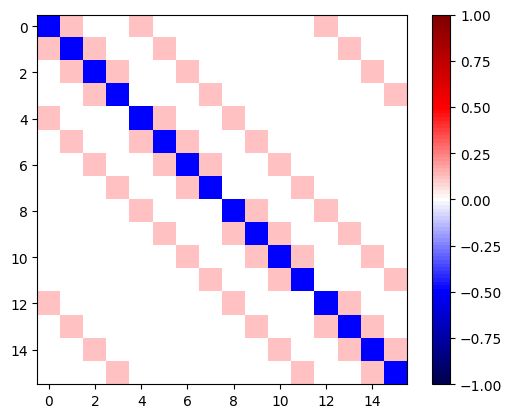

Boundary condition: neumann , neumann


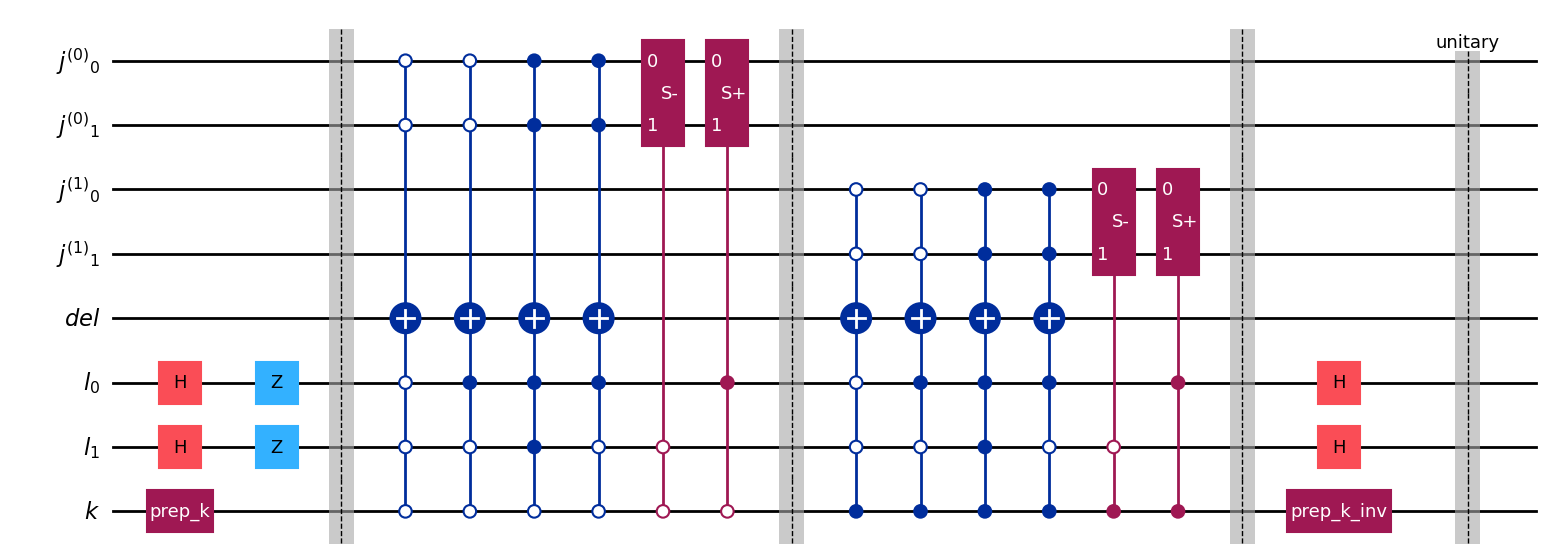

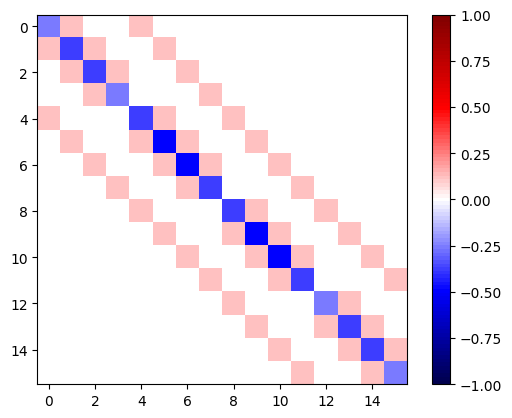

Boundary condition: neumann , dirichlet


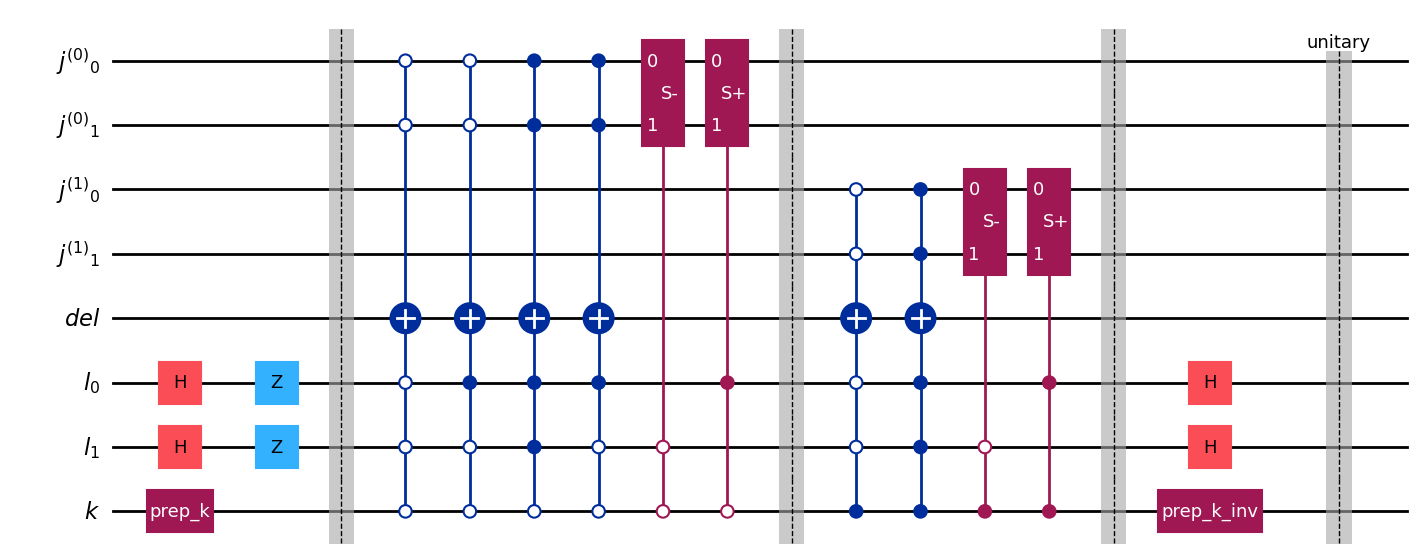

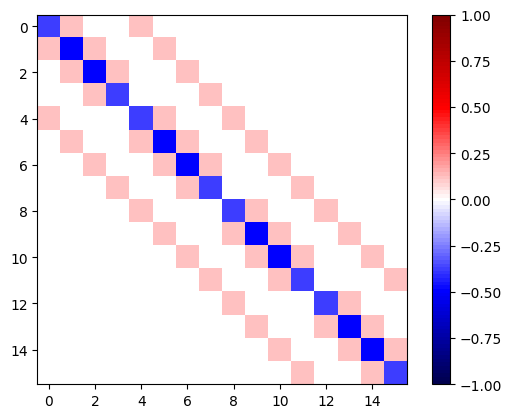

In [4]:
# Heat map and quantum circuit plots of our block encodings of  2D Laplacians
bcs = [("dirichlet", "periodic"), ("neumann", "neumann"), ("neumann", "dirichlet")] # total 9 combinations possible

for bc in bcs:
    print("Boundary condition:", bc[0], ',' , bc[1])
    nqs= [2, 2]  # number of qubits in each dimension, 2^2 = 4 grid points per dimension
    qc = generate_laplacian_block_encoding(nqs, bcs=bc, save_unitary=True)
    fig = qc.draw(output="mpl")
    display(fig)
    plot_heatmap(qc, nqs=nqs, bcs=bc)

### Correctness check for 2D Laplacian

In [5]:
test_names = ["2D DP", "2D NN", "2D ND"]

for i, bc in enumerate(bcs):
    grid_points= (2**i for i in nqs)
    correct_mat = generate_laplacian(grid_points, (1, 1), bc, True).toarray()

    qc = generate_laplacian_block_encoding(nqs, bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, nqs)

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")


--- PASSED ---	Test 2D DP
--- PASSED ---	Test 2D NN
--- PASSED ---	Test 2D ND


## 3D Laplacian 

Boundary condition: dirichlet periodic neumann


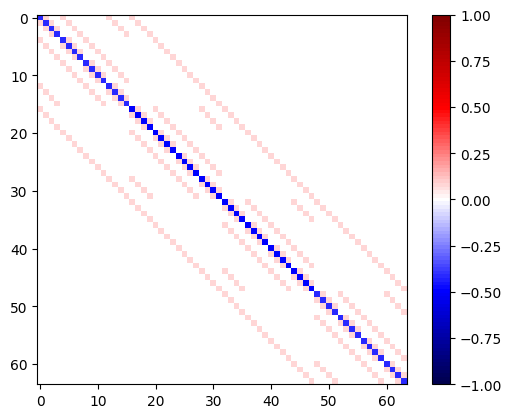

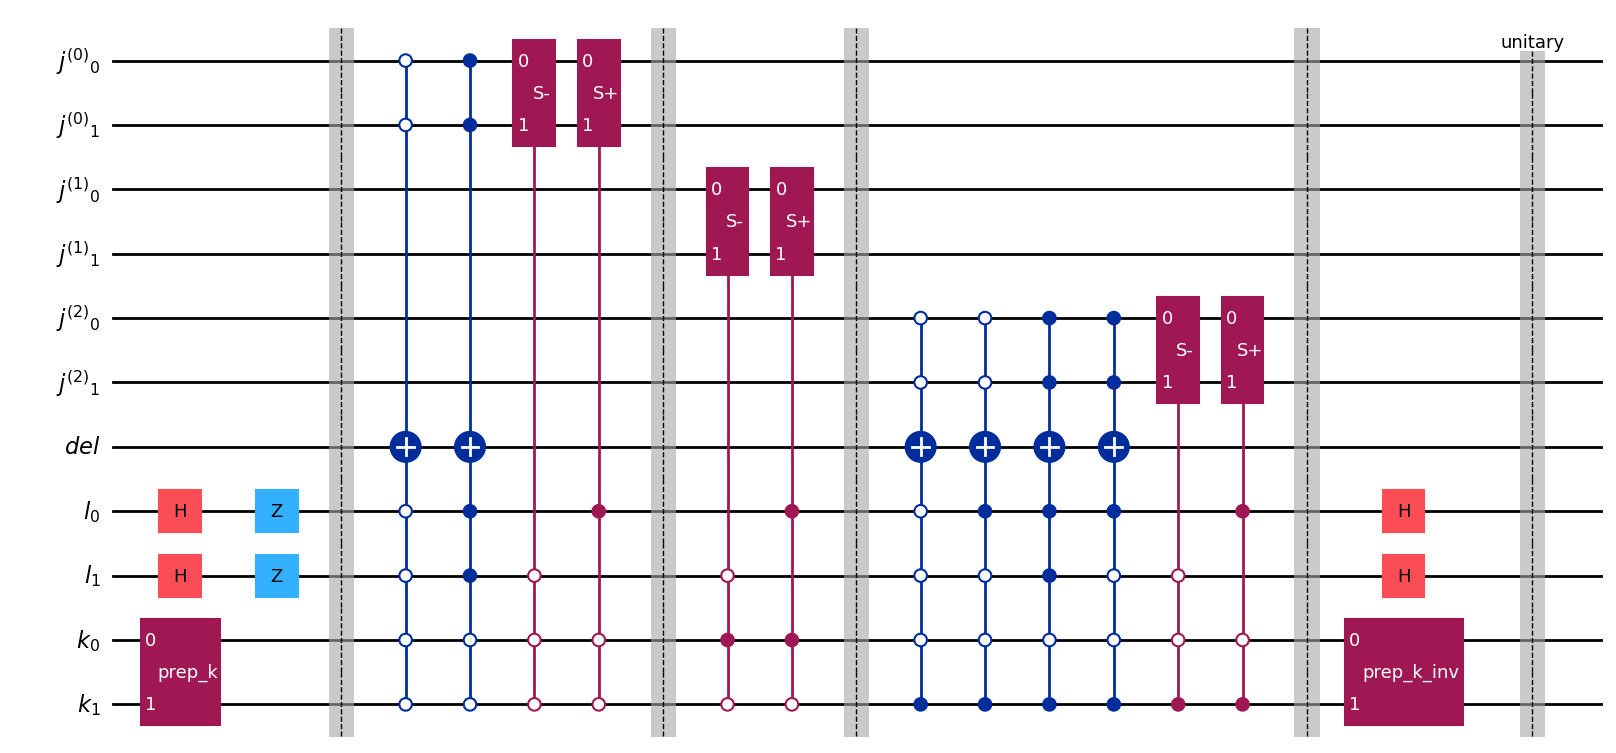

Boundary condition: neumann neumann neumann


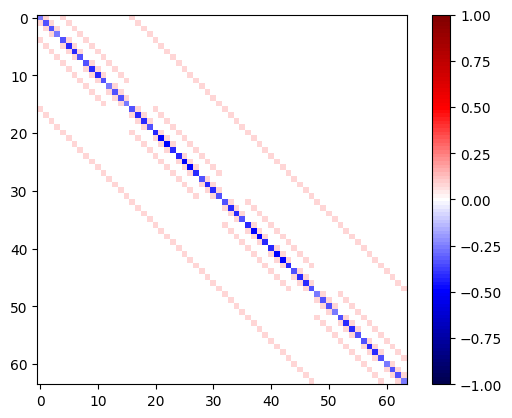

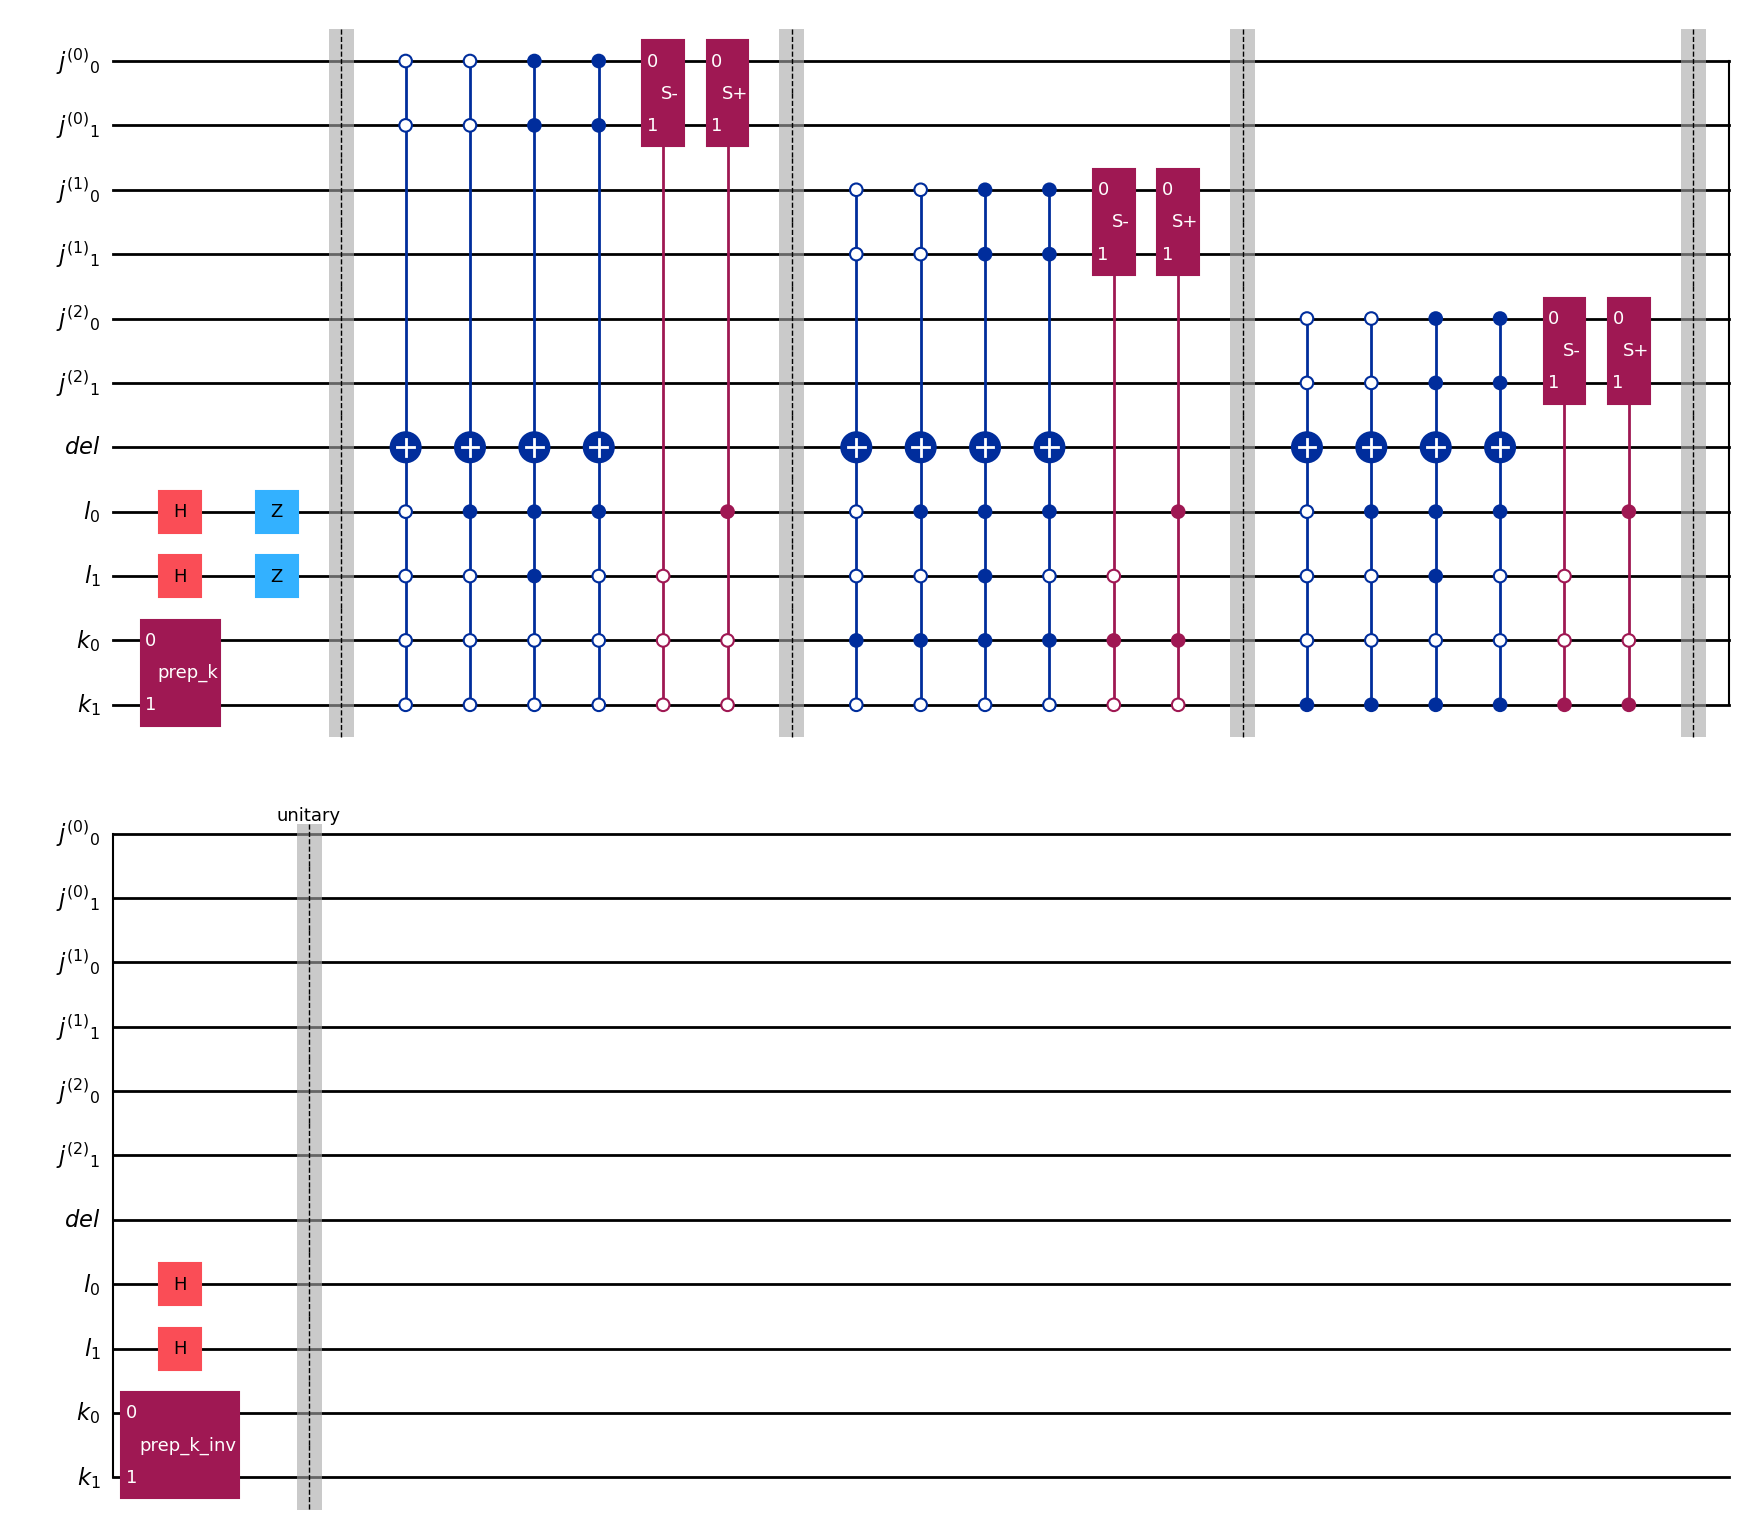

In [6]:
# Heat map and quantum circuit plots of our block encodings of 3D Laplacians
bcs = [("dirichlet", "periodic", "neumann"), ("neumann", "neumann", "neumann")]
test_names = ["3D DPN", "3D NNN"] # total 27 possible combinations, but just showing two here

for bc in bcs:
    print("Boundary condition:", bc[0], bc[1], bc[2])
    nqs= [2, 2, 2]  # number of qubits in each dimension, 2^2 = 4 grid points per dimension
    qc = generate_laplacian_block_encoding(nqs, bcs=bc, save_unitary=True)
    plot_heatmap(qc, nqs=nqs, bcs=bc)
    fig = qc.draw(output="mpl")
    display(fig)



In [7]:
for i, bc in enumerate(bcs):
    grid_points= (2**i for i in nqs)
    correct_mat = generate_laplacian(grid_points, (1, 1, 1), bc, True).toarray()

    qc = generate_laplacian_block_encoding(nqs, bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, nqs)

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

--- PASSED ---	Test 3D DPN
--- PASSED ---	Test 3D NNN


## Varied grid points and grid sizes across dimensions

Boundary condition: dirichlet periodic neumann


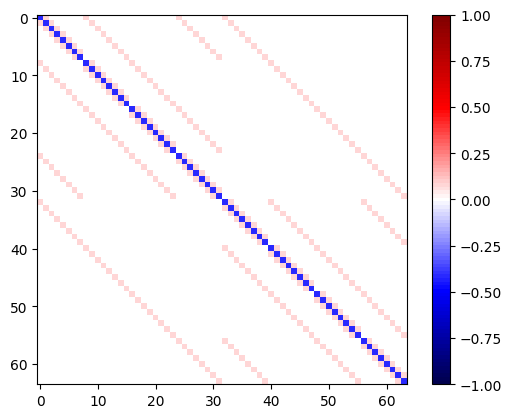

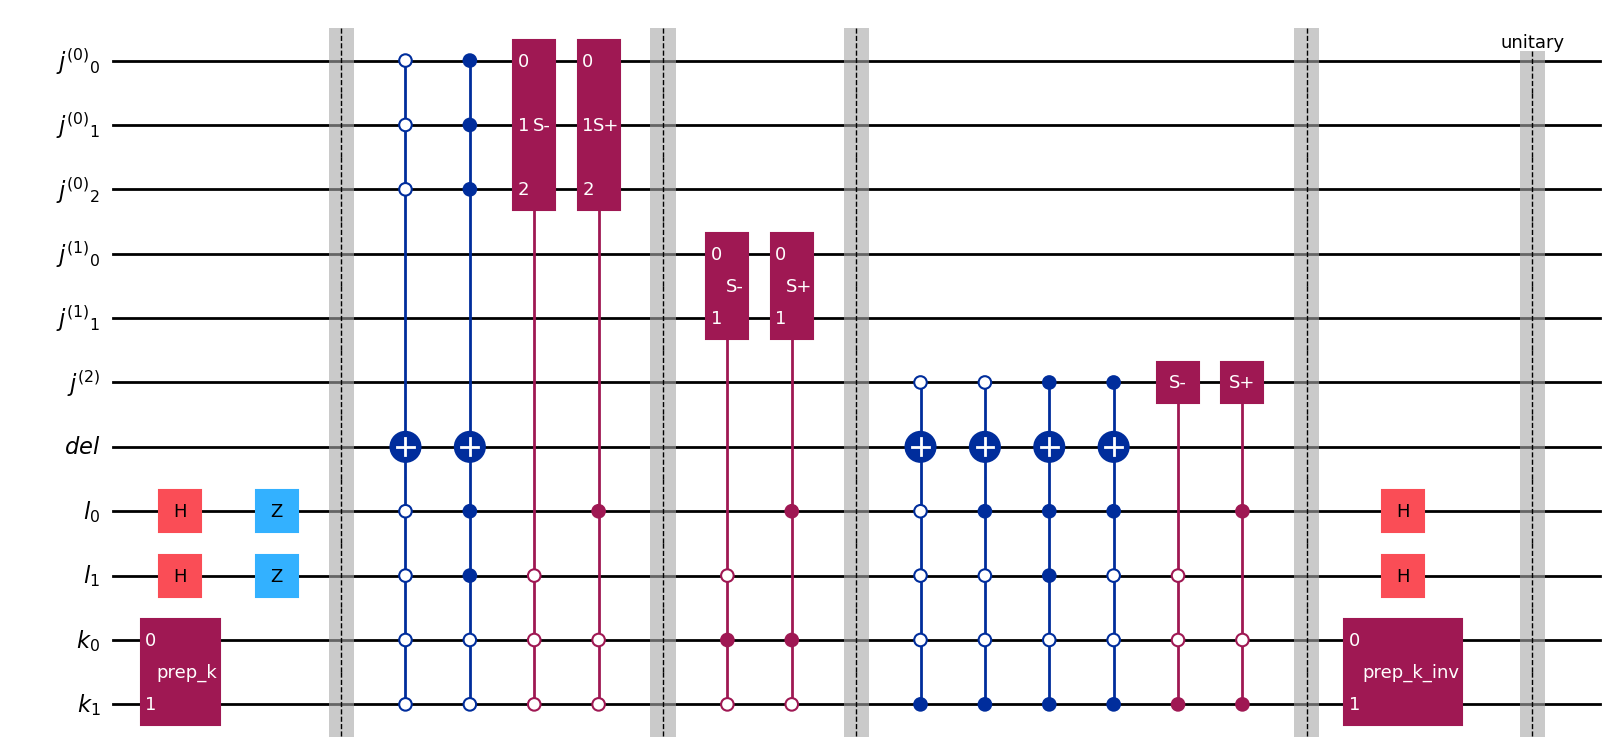

--- PASSED ---	Test 3D DPN with grid variations


In [8]:
# 3D Laplacians with varied grid points and spacings
bcs = [("dirichlet", "periodic", "neumann")]
test_names = ["3D DPN with grid variations"]


for bc in bcs:
    print("Boundary condition:", bc[0], bc[1], bc[2])
    nqs= [3, 2, 1]  # number of qubits in each dimension, 2^3=8, 2^2=4, 2^1=2 grid points respectively
    qc = generate_laplacian_block_encoding(nqs, bcs=bc, save_unitary=True)
    plot_heatmap(qc, nqs=nqs, bcs=bc)
    fig = qc.draw(output="mpl")
    display(fig)

for i, bc in enumerate(bcs):
    nqs= [3, 2, 1]  # number of qubits in each dimension, 2^3=8, 2^2=4, 2^1=2 grid points respectively
    grid_points= (2**i for i in nqs)
    correct_mat = generate_laplacian(grid_points, (1, 0.5, 0.2), bc, True).toarray()

    qc = generate_laplacian_block_encoding(nqs, deltas=[1, 0.5, 0.2], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, nqs)

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

___
___